Предыдущий код - нужен для дальнейших работ

In [11]:
# Импорт необходимых библиотек
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns

In [12]:
# Генерация искусственного датасета
def generate_braking_data(n_samples=100, noise_level=10, random_state=42):
    """
    Генерирует данные с нормальным шумом (физически корректные).
    """
    np.random.seed(random_state)

    # Генерируем скорости от 1 до 30 м/с (108 км/ч)
    v = np.linspace(1, 30, n_samples)

    # Физическая зависимость: s = v²/(2a), где a ≈ 4 м/с²
    s_ideal = v**2 / (2 * 4)

    # Добавляем нормальный шум
    noise = np.random.normal(0, noise_level, n_samples)
    s = s_ideal + noise

    # убираем отрицательные тормозные пути
    s = np.maximum(s, 0.1)  # Все значения меньше 0.1 становятся 0.1

    return v, s

In [13]:
# Создаем dataset
v, s = generate_braking_data(n_samples=500)

In [14]:
# Добавляем фиктивный признак x₀ = 1
X = np.column_stack([np.ones(len(v)), v])  # X = [1, v]

In [15]:
# Реализация функций

def compute_predictions(X, theta):
    """Вычисление предсказаний: Xθ"""
    return X @ theta

def compute_loss(X, y, theta):
    """Функция потерь MSE: L(θ) = 1/(2n) * Σ(y_i - x_iθ)²"""
    n = len(y)
    errors = y - compute_predictions(X, theta)
    return (1 / (2 * n)) * np.sum(errors ** 2)

def compute_gradient(X, y, theta):
    """Градиент: ∇L(θ) = (1/n) * Xᵀ(Xθ - y)"""
    n = len(y)
    predictions = compute_predictions(X, theta)
    errors = predictions - y
    return (1 / n) * X.T @ errors

In [16]:
# Проверим работу функций на нулевых начальных параметрах
theta_init = np.array([0.0, 0.0]) #Т.е. получается у нас тупо прямая y = 0
# loss_init = compute_loss(X, s, theta_init)
# gradient_init = compute_gradient(X, s, theta_init)

In [17]:
def gradient_descent(X, y, initial_theta, learning_rate=0.001, n_iterations=100):
    """Реализация градиентного спуска"""
    theta = initial_theta.copy()
    loss_history = []

    for i in range(n_iterations):
        # Вычисляем градиент
        gradient = compute_gradient(X, y, theta)

        # Обновляем параметры
        theta = theta - learning_rate * gradient

        # Сохраняем значение функции потерь
        loss = compute_loss(X, y, theta)
        loss_history.append(loss)

    return theta, loss_history

# Задание: Изучение работы градиентного спуска и улучшение модели

##  1: Исследование шага обучения
Проведите эксперименты с разными значениями шага обучения (η). Попробуйте (это примерные значения):
- Очень маленькие: 0.00001, 0.0001
- Умеренные: 0.001, 0.005  
- Слишком большие: 0.01, 0.1

Для каждого η:
1. Запустите градиентный спуск на 100 итераций (или другое число)
2. Постройте график функции потерь
3. Найдите случаи: медленная сходимость, хорошая сходимость, расходимость


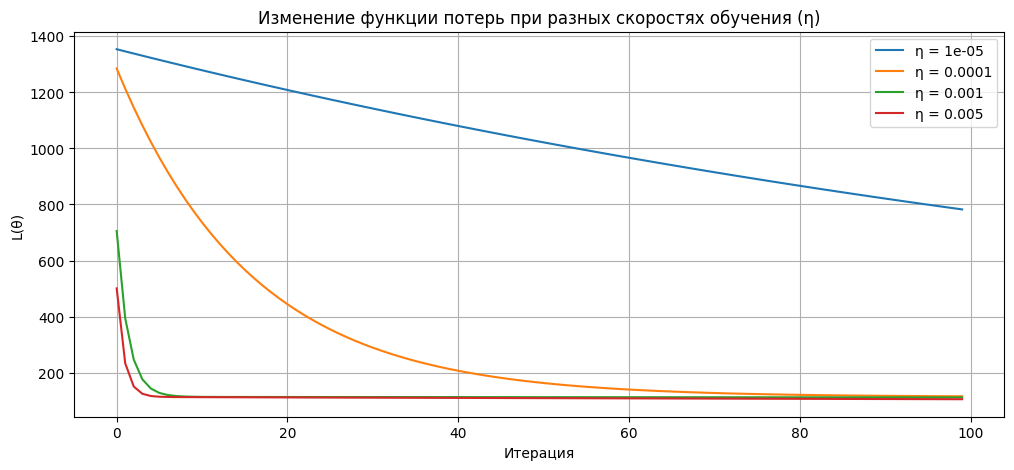

η = 1e-05
  → θ₀ = 0.034, θ₁ = 0.757
  → Конечная ошибка: L(θ) = 782.3879

η = 0.0001
  → θ₀ = 0.092, θ₁ = 2.709
  → Конечная ошибка: L(θ) = 116.2001

η = 0.001
  → θ₀ = -0.285, θ₁ = 2.848
  → Конечная ошибка: L(θ) = 112.3389

η = 0.005
  → θ₀ = -1.896, θ₁ = 2.928
  → Конечная ошибка: L(θ) = 105.8343



In [28]:
#Рассмотрим при Очень маленькие: 0.00001, 0.0001
etas = [0.00001, 0.0001, 0.001, 0.005]
results = {}

for eta in etas:
    theta_opt, loss_hist = gradient_descent(X, s, theta_init, learning_rate=eta, n_iterations=100)
    results[eta] = (theta_opt, loss_hist)

# === Визуализация ===
plt.figure(figsize=(12, 5))

for eta, (_, loss_hist) in results.items():
    plt.plot(loss_hist, label=f"η = {eta}")

plt.title("Изменение функции потерь при разных скоростях обучения (η)")
plt.xlabel("Итерация")
plt.ylabel("L(θ)")
plt.legend()
plt.grid(True)
plt.show()

# === Пояснение ===
for eta, (theta, loss) in results.items():
    print(f"η = {eta}")
    print(f"  → θ₀ = {theta[0]:.3f}, θ₁ = {theta[1]:.3f}")
    print(f"  → Конечная ошибка: L(θ) = {loss[-1]:.4f}\n")

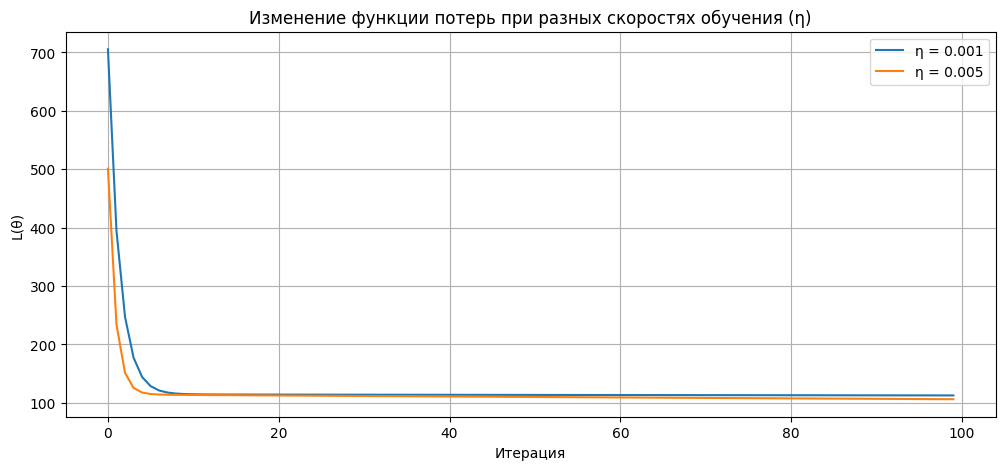

η = 0.001
  → θ₀ = -0.285, θ₁ = 2.848
  → Конечная ошибка: L(θ) = 112.3389

η = 0.005
  → θ₀ = -1.896, θ₁ = 2.928
  → Конечная ошибка: L(θ) = 105.8343



In [29]:
#Рассмотрим при Умеренные: 0.001, 0.005
etas = [0.001, 0.005]
results = {}

for eta in etas:
    theta_opt, loss_hist = gradient_descent(X, s, theta_init, learning_rate=eta, n_iterations=100)
    results[eta] = (theta_opt, loss_hist)

# === Визуализация ===
plt.figure(figsize=(12, 5))

for eta, (_, loss_hist) in results.items():
    plt.plot(loss_hist, label=f"η = {eta}")

plt.title("Изменение функции потерь при разных скоростях обучения (η)")
plt.xlabel("Итерация")
plt.ylabel("L(θ)")
plt.legend()
plt.grid(True)
plt.show()

# === Пояснение ===
for eta, (theta, loss) in results.items():
    print(f"η = {eta}")
    print(f"  → θ₀ = {theta[0]:.3f}, θ₁ = {theta[1]:.3f}")
    print(f"  → Конечная ошибка: L(θ) = {loss[-1]:.4f}\n")

C:\Users\nikit\AppData\Local\Temp\ipykernel_16464\2906414342.py:11: RuntimeWarning: overflow encountered in square
  return (1 / (2 * n)) * np.sum(errors ** 2)
C:\Users\nikit\AppData\Local\Temp\ipykernel_16464\2906414342.py:18: RuntimeWarning: overflow encountered in matmul
  return (1 / n) * X.T @ errors
C:\Users\nikit\AppData\Local\Temp\ipykernel_16464\3509733111.py:11: RuntimeWarning: invalid value encountered in subtract
  theta = theta - learning_rate * gradient


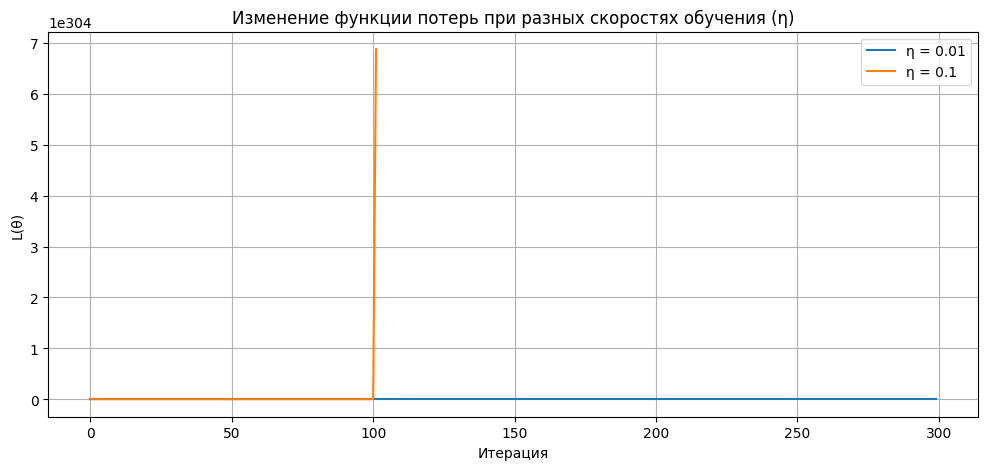

η = 0.01
  → θ₀ = -4719790969209348355291698740484758136411341178693009605551660941504772291874063982447475659112448.000, θ₁ = -94514045283085422856882892432081983029394775913826995883260996306516133118868910489738913268105216.000
  → Конечная ошибка: L(θ) = 1394269138839732237219978611721629328653742723923065876064943714545385246970134568873946282330030562361092232557623551460807446150481301267464004761531911672626164193965861721445991822036326722568192.0000

η = 0.1
  → θ₀ = nan, θ₁ = nan
  → Конечная ошибка: L(θ) = nan



In [36]:
#Рассмотрим при Большие: 0.01, 0.1
etas = [0.01, 0.1]
results = {}

for eta in etas:
    theta_opt, loss_hist = gradient_descent(X, s, theta_init, learning_rate=eta, n_iterations=300)
    results[eta] = (theta_opt, loss_hist)

# === Визуализация ===
plt.figure(figsize=(12, 5))

for eta, (_, loss_hist) in results.items():
    plt.plot(loss_hist, label=f"η = {eta}")

plt.title("Изменение функции потерь при разных скоростях обучения (η)")
plt.xlabel("Итерация")
plt.ylabel("L(θ)")
plt.legend()
plt.grid(True)
plt.show()

# === Пояснение ===
for eta, (theta, loss) in results.items():
    print(f"η = {eta}")
    print(f"  → θ₀ = {theta[0]:.3f}, θ₁ = {theta[1]:.3f}")
    print(f"  → Конечная ошибка: L(θ) = {loss[-1]:.4f}\n")